In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(2200)

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
import os
os.chdir('/content/gdrive/MyDrive/Problem Set 4 IDAI 610')

In [7]:
pip freeze > '/content/gdrive/MyDrive/Problem Set 4 IDAI 610/requirements.txt'

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Problem Set 4 IDAI 610/Titanic-Dataset.csv')

For this problem, the Target/ dependent variable is Fare and independent feature variable is Age

Checking for null values in the dataset

In [ ]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Understanding the correlation amongst Fare and Age through a heatmap

<Axes: >

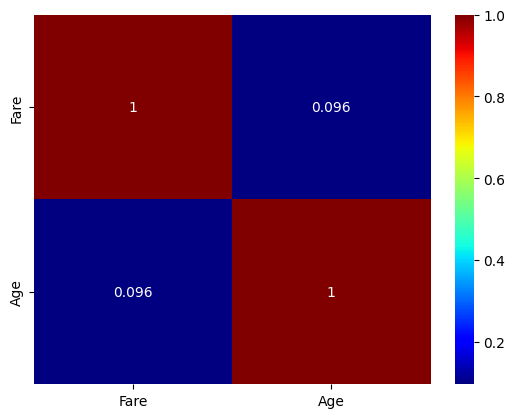

In [ ]:
test_df = df[['Fare', 'Age']]

sns.heatmap(test_df.corr(), annot=True, cmap='jet')

# Approach 1: Removing all the rows in which Age is Null to build the regression model using gradient descent

In [ ]:
new_df = df.dropna()
new_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
len(df), len(new_df)

(891, 183)

By removing the rows, there is a significant loss in information here

<Axes: >

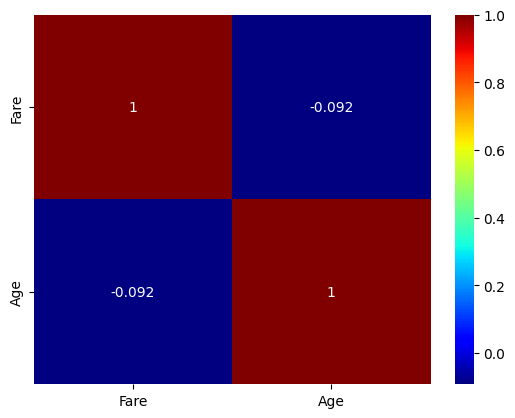

In [ ]:
test_df = new_df[['Fare', 'Age']]

sns.heatmap(test_df.corr(), annot=True, cmap='jet')

In [ ]:
df = new_df

Text(0, 0.5, 'Fare')

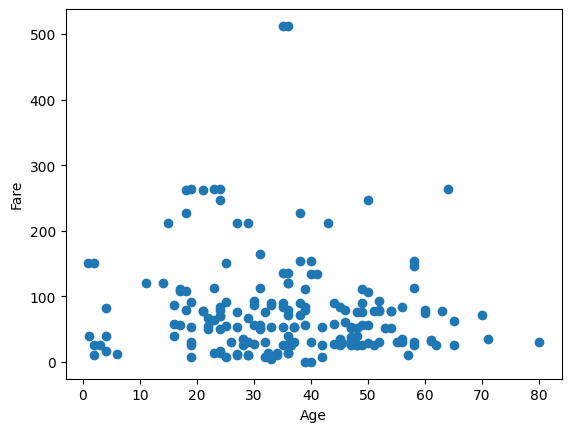

In [ ]:
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')

In [ ]:
df = df[df['Fare'] <= 300]

Text(0, 0.5, 'Fare')

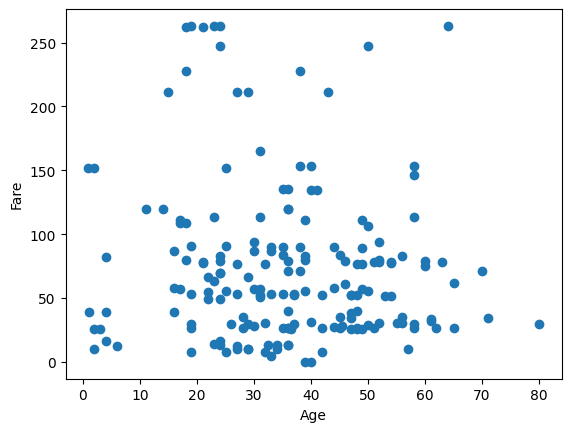

In [ ]:
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')

In [ ]:
def visualise_MSE_vs_iter(record):
    plt.figure(figsize=(10,6))
    line_styles = ['solid', 'dashed', 'dashdot']
    line_width = 2.2
    color = 'black'

    for (lr, mse_values), style in zip(record.items(), line_styles):
        plt.plot(
            range(1, epochs+1),
            mse_values,
            linestyle=style,
            linewidth=line_width,
            color=color,
            label=f"lr = {lr}")
    plt.xlabel("Iterations")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

import matplotlib.pyplot as plt

def visualise_MSE_vs_iter_without_norm(dictionary):
    line_styles = {
        0.001: ('solid', 2.2),   # thick solid
        0.01:  ('dashed', 2.0),  # thick dashed
        0.5:   ('dashdot', 2.0)  # thick dash-dot
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -------------------- LEFT PLOT: lr = 0.001 --------------------
    lr = 0.001
    style, lw = line_styles[lr]

    axes[0].plot(
        range(1, epochs+1),
        dictionary[lr],
        linestyle=style,
        linewidth=lw,
        color='black',
        label=f"lr = {lr}"
    )

    axes[0].set_xlabel("Iterations")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Learning Rate = 0.001")
    axes[0].legend()
    axes[0].grid(True)

    # -------------------- RIGHT PLOT: lr = 0.01 and 0.5 --------------------
    for lr in [0.01, 0.5]:
        style, lw = line_styles[lr]
        axes[1].plot(
            range(1, epochs+1),
            master_dict[lr],
            linestyle=style,
            linewidth=lw,
            color='black',
            label=f"lr = {lr}"
        )

    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("MSE")
    axes[1].set_title("Learning Rates: 0.01 and 0.5")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
def pred_fn(new_x, m, c):
    y = m*new_x + c
    return y

def calc_rsq(pred_df, m, c):
    pred_df['y_hat'] = pred_df['Fare'].apply(lambda new_x: pred_fn(new_x, m, c))
    pred_df['yi-y_hat'] =  (pred_df['Fare'] - pred_df['y_hat'])**2
    pred_df['yi-y_mean'] =  (pred_df['Fare'] - np.mean(pred_df['Fare']))**2

    SS_res = sum(pred_df['yi-y_hat'])
    SS_tot = sum(pred_df['yi-y_mean'])
    r_sq = 1 - (SS_res/SS_tot)
    return r_sq

In [ ]:
def gradient_descent(df, epochs, lr, w, b, norm=False):
    MSE_record = []
    m = len(df)

    if norm:
        # Standardize both x and y because y values are greater by a large extent when compared to x
        df['Age_scaled'] =  (df['Age'] - df['Age'].mean()) / df['Age'].std()
        df['Fare_scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()

        # Gradient descent loop
        for i in range(epochs):
            # Compute predictions using scaled x
            y_pred = w * df['Age_scaled'] + b

            # Compute residuals between scaled y and predicted values
            residuals = y_pred - df['Fare_scaled']

            MSE = (1/(2*m))*(residuals**2).sum()
            MSE_record.append(MSE)

            # Compute partial derivatives (gradients)
            par_der_w = (1/m) * (df['Age_scaled'] * residuals).sum()  # Derivative w.r.t slope or the weight
            par_der_b = (1/m) * residuals.sum()  # Derivative w.r.t intercept or the bias

            # Update intercept and slope
            w = w - lr * par_der_w
            b = b - lr * par_der_b
    else:
        # Gradient descent loop
        for i in range(epochs):
            # Compute predictions using scaled x
            y_pred = w * df['Age'] + b

            # Compute residuals between scaled y and predicted values
            residuals = y_pred - df['Fare']

            MSE = (1/(2*m))*(residuals**2).sum()
            MSE_record.append(MSE)

            # Compute partial derivatives (gradients)
            par_der_w = (1/m) * (df['Age'] * residuals).sum()  # Derivative w.r.t slope or the weight
            par_der_b = (1/m) * residuals.sum()  # Derivative w.r.t intercept or the bias

            # Update intercept and slope
            w = w - lr * par_der_w
            b = b - lr * par_der_b


    # Convert the learned slope and intercept back to the original scale
    w_orig = w * (df['Fare'].std() / df['Age'].std())
    b_orig = df['Fare'].mean() - w_orig * df['Age'].mean() # y=mx+c

    return w_orig, b_orig, MSE_record

In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.01  # Learning rate
epochs = 1000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=False)
print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

# visualise_MSE_vs_iter({lr:MSE_record})

/tmp/ipython-input-1741823292.py:45: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * par_der_w


Final values -> Intercept (b): nan, Slope (w): nan
R^2 value: nan


/tmp/ipython-input-3447228544.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df['y_hat'] = pred_df['Fare'].apply(lambda new_x: pred_fn(new_x, m, c))
/tmp/ipython-input-3447228544.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df['yi-y_hat'] =  (pred_df['Fare'] - pred_df['y_hat'])**2
/tmp/ipython-input-3447228544.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

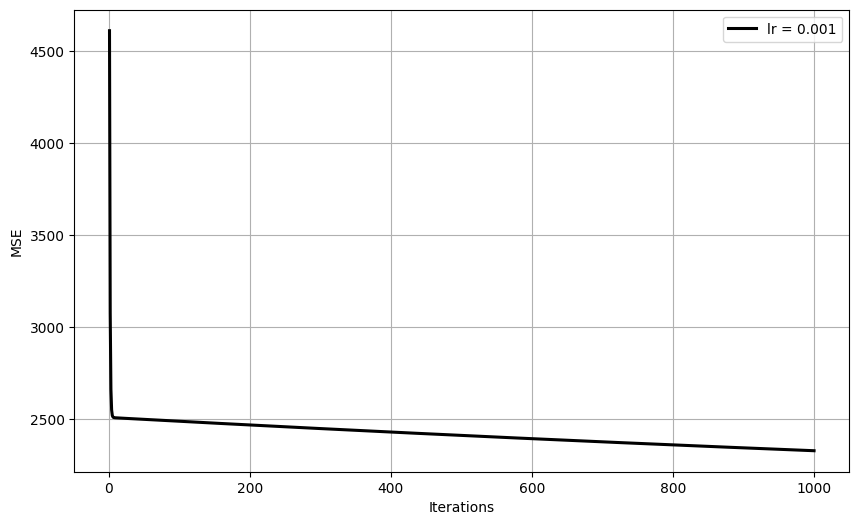

Final values -> Intercept (b): -113.95298364688475, Slope (w): 5.265217910572045
R^2 value: -27.95823009955855


/tmp/ipython-input-3447228544.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df['y_hat'] = pred_df['Fare'].apply(lambda new_x: pred_fn(new_x, m, c))
/tmp/ipython-input-3447228544.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df['yi-y_hat'] =  (pred_df['Fare'] - pred_df['y_hat'])**2
/tmp/ipython-input-3447228544.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.001  # Learning rate
epochs = 1000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=False)
visualise_MSE_vs_iter({lr:MSE_record})

print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

/tmp/ipython-input-1741823292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_scaled'] =  (df['Age'] - df['Age'].mean()) / df['Age'].std()
/tmp/ipython-input-1741823292.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()


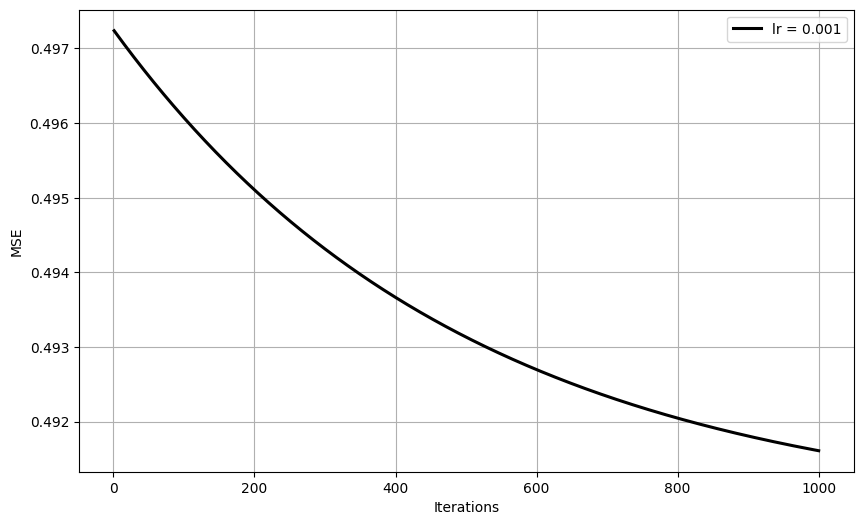

Final values -> Intercept (b): 83.95610520595547, Slope (w): -0.28212841077054623
R^2 value: -0.6747648429290136


/tmp/ipython-input-3447228544.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df['y_hat'] = pred_df['Fare'].apply(lambda new_x: pred_fn(new_x, m, c))


In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.001  # Learning rate
epochs = 1000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=True)
visualise_MSE_vs_iter({lr:MSE_record})
print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

/tmp/ipython-input-1741823292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_scaled'] =  (df['Age'] - df['Age'].mean()) / df['Age'].std()
/tmp/ipython-input-1741823292.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()


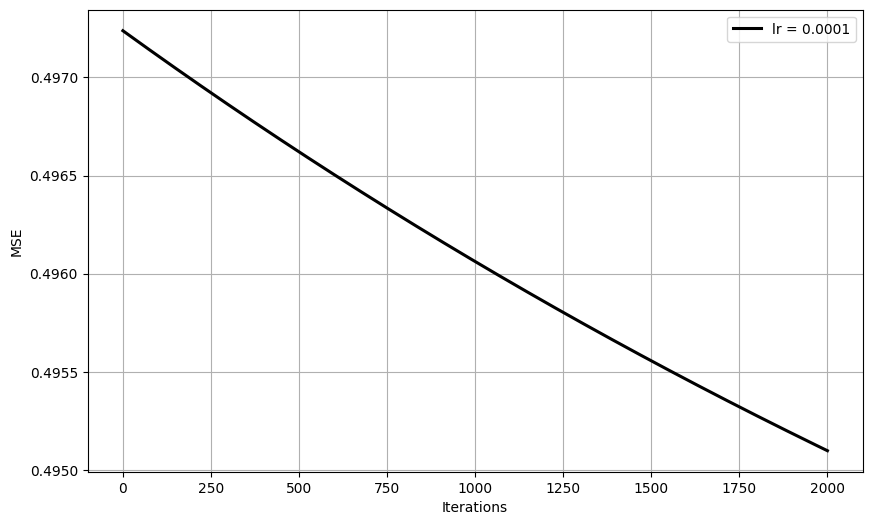

Final values -> Intercept (b): 76.77132844310401, Slope (w): -0.08074076770627067
R^2 value: -0.1705323132988521


/tmp/ipython-input-3447228544.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df['y_hat'] = pred_df['Fare'].apply(lambda new_x: pred_fn(new_x, m, c))


In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.0001  # Learning rate
epochs = 2000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=True)
visualise_MSE_vs_iter({lr:MSE_record})
print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

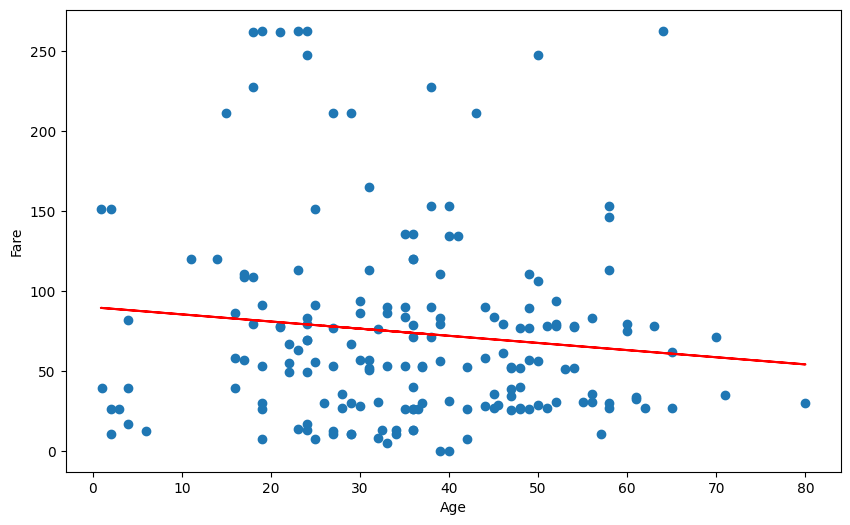

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'], df['Fare'])
plt.plot(df['Age'], b_orig + w_orig*df['Age'], 'r')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

## Comparison plot of lr = 0.001, 0.1, 0.5

### without normalization

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/tmp/ipython-input-1741823292.py:45: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * par_der_w
/tmp/ipython-input-1741823292.py:46: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - lr * par_der_b


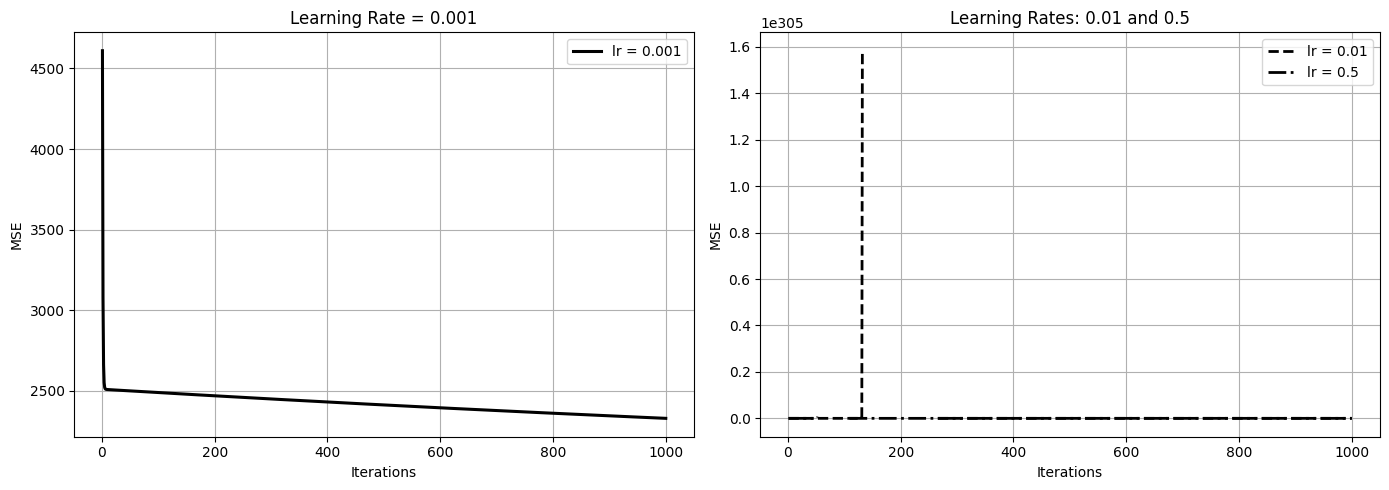

In [ ]:
master_dict = {}
for lr in [0.001, 0.01, 0.5]:
    w, b = 0, 0  # Starting guess for intercept and slope
    epochs = 1000  # Number of iterations
    w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=False)

    master_dict[lr] = MSE_record

visualise_MSE_vs_iter_without_norm(master_dict)

with z score normalization

/tmp/ipython-input-1741823292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_scaled'] =  (df['Age'] - df['Age'].mean()) / df['Age'].std()
/tmp/ipython-input-1741823292.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()


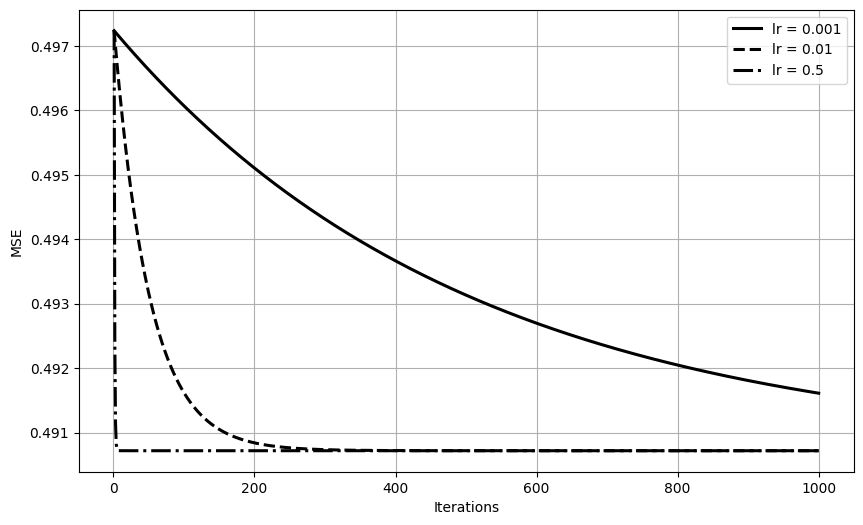

In [ ]:
master_dict = {}
for lr in [0.001, 0.01, 0.5]:
    w, b = 0, 0  # Starting guess for intercept and slope
    epochs = 1000  # Number of iterations
    w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=True)

    master_dict[lr] = MSE_record

visualise_MSE_vs_iter(master_dict)

# Imputing Empty values in Age using K Nearest Neighbor

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Problem Set 4 IDAI 610/Titanic-Dataset.csv')

# Drop text-heavy columns we can't use for KNN
df_knn = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors='ignore')

# One-hot encode categorical columns
df_knn = pd.get_dummies(df_knn, columns=["Sex", "Embarked"], drop_first=True)

print("Missing values BEFORE KNN:\n")
print(df_knn.isna().sum())

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

# Fit & transform
df_imputed_values = imputer.fit_transform(df_knn)

# Convert back to DataFrame with correct column names
df_imputed = pd.DataFrame(df_imputed_values, columns=df_knn.columns)

print("\nMissing values AFTER KNN:\n")
print(df_imputed.isna().sum())


Missing values BEFORE KNN:

Survived        0
Pclass          0
Age           177
SibSp           0
Parch           0
Fare            0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64

Missing values AFTER KNN:

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
len(df), len(df_imputed)

(891, 891)

<Axes: >

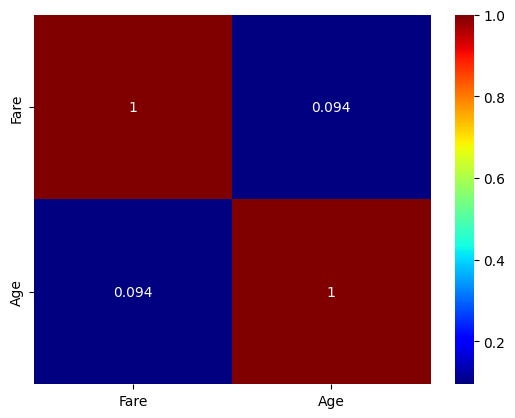

In [ ]:
test_df = df_imputed[['Fare', 'Age']]

sns.heatmap(test_df.corr(), annot=True, cmap='jet')

Text(0, 0.5, 'Fare')

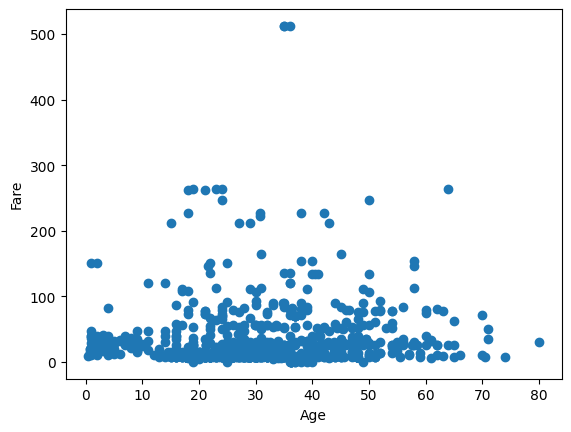

In [ ]:
plt.scatter(df_imputed['Age'], df_imputed['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')

In [ ]:
df_imputed = df_imputed[df_imputed['Fare'] <= 300]

Text(0, 0.5, 'Fare')

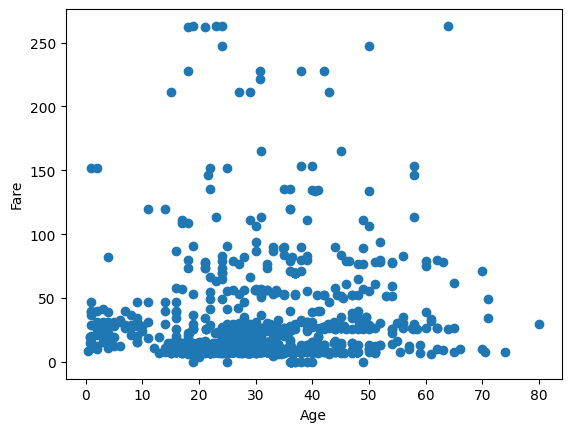

In [ ]:
plt.scatter(df_imputed['Age'], df_imputed['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')

In [ ]:
len(df), len(df_imputed)

(891, 888)

In [ ]:
df = df_imputed

In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.01  # Learning rate
epochs = 1000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=False)
print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

# visualise_MSE_vs_iter({lr:MSE_record})

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/tmp/ipython-input-1741823292.py:45: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * par_der_w


Final values -> Intercept (b): nan, Slope (w): nan
R^2 value: nan


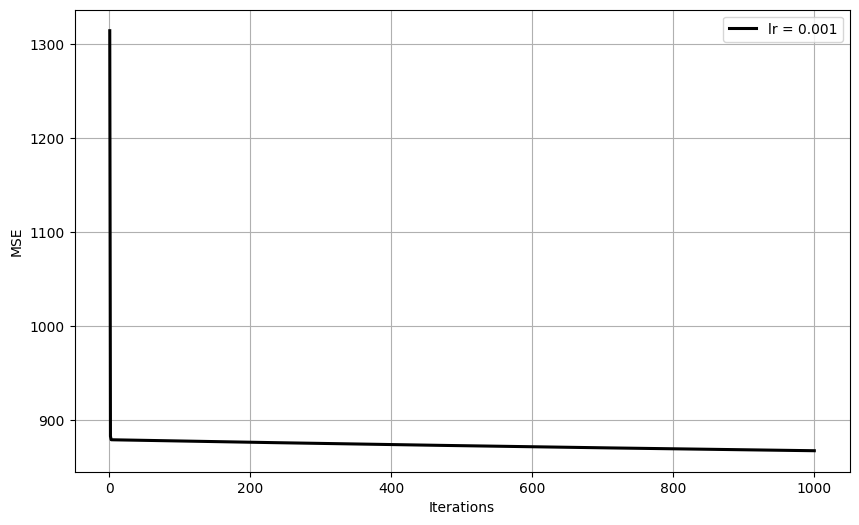

Final values -> Intercept (b): -41.510526397194525, Slope (w): 2.3987087974053964
R^2 value: -0.9573311981570565


In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.001  # Learning rate
epochs = 1000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=False)
visualise_MSE_vs_iter({lr:MSE_record})

print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

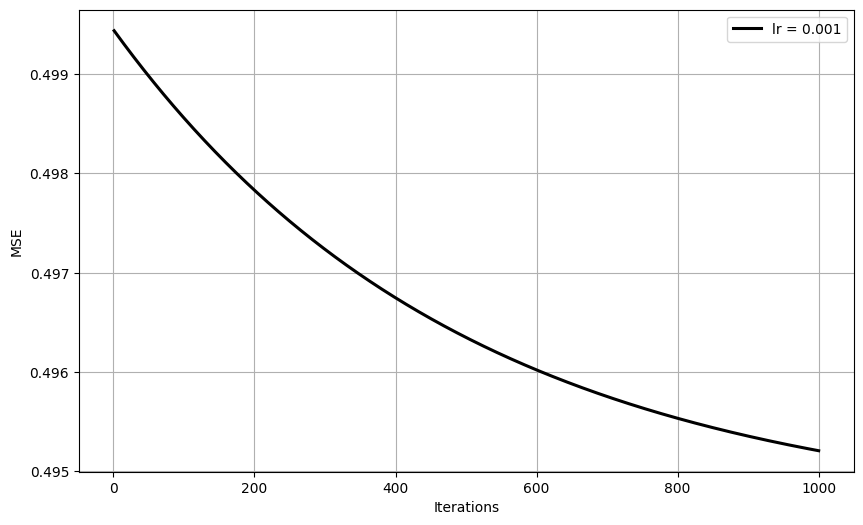

Final values -> Intercept (b): 24.93730381957102, Slope (w): 0.18781898510958744
R^2 value: 0.3403562059792229


In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.001  # Learning rate
epochs = 1000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=True)
visualise_MSE_vs_iter({lr:MSE_record})
print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

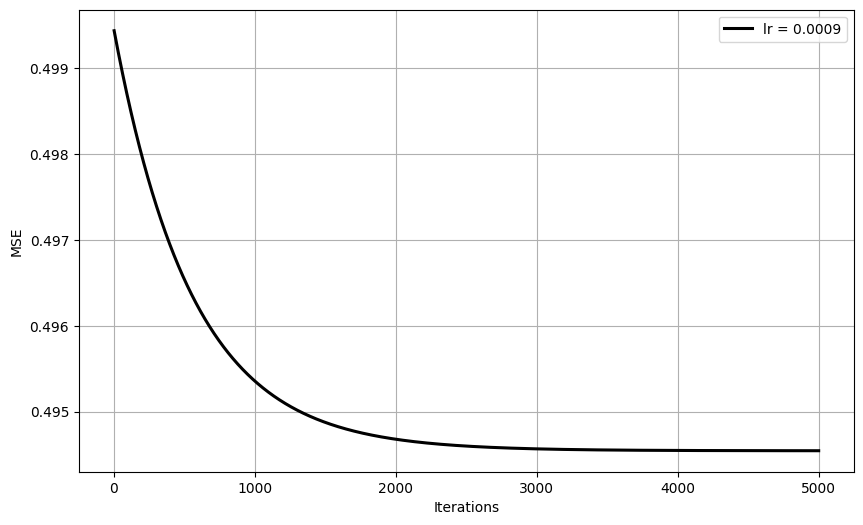

Final values -> Intercept (b): 21.748408991453097, Slope (w): 0.29392169854611805
R^2 value: 0.5014392451277128


In [ ]:
# Initialize parameters
w, b = 0, 0  # Starting guess for intercept and slope
lr = 0.0009  # Learning rate
epochs = 5000  # Number of iterations

w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=True)
visualise_MSE_vs_iter({lr:MSE_record})
print(f"Final values -> Intercept (b): {b_orig}, Slope (w): {w_orig}")
print(f"R^2 value: {calc_rsq(df, w_orig, b_orig)}")

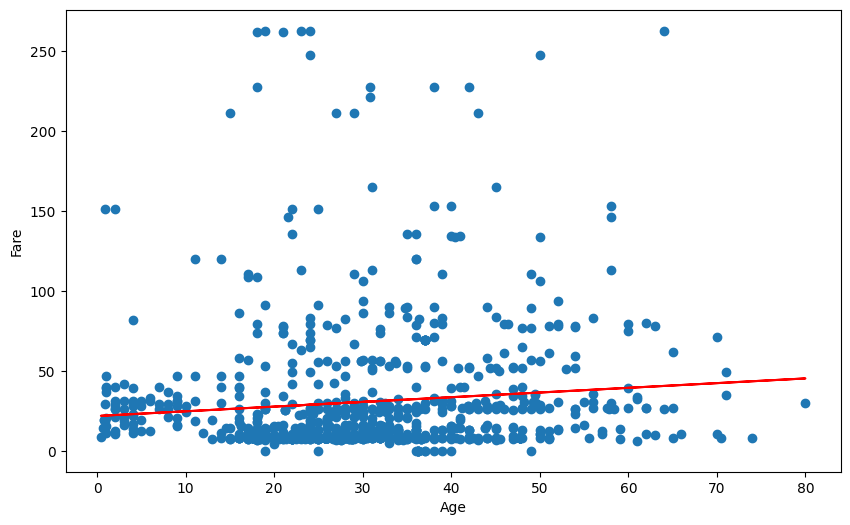

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'], df['Fare'])
plt.plot(df['Age'], b_orig + w_orig*df['Age'], 'r')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

## Comparison plot of lr = 0.001, 0.1, 0.5

without normalization

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/tmp/ipython-input-1741823292.py:45: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * par_der_w


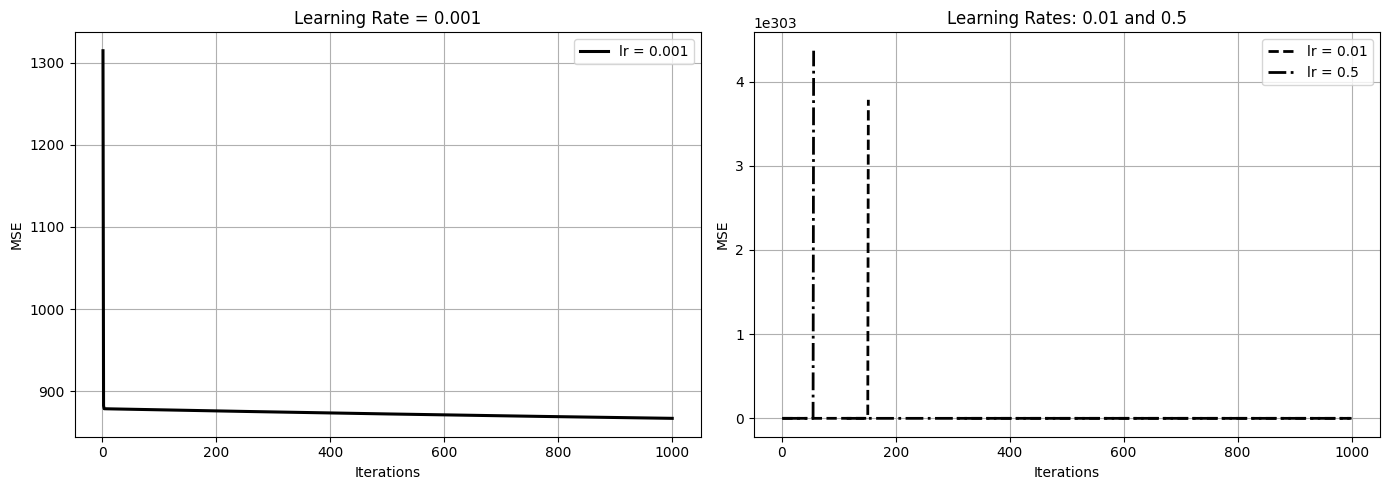

In [ ]:
master_dict = {}
for lr in [0.001, 0.01, 0.5]:
    w, b = 0, 0  # Starting guess for intercept and slope
    epochs = 1000  # Number of iterations
    w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=False)

    master_dict[lr] = MSE_record

visualise_MSE_vs_iter_without_norm(master_dict)

with z score normalization

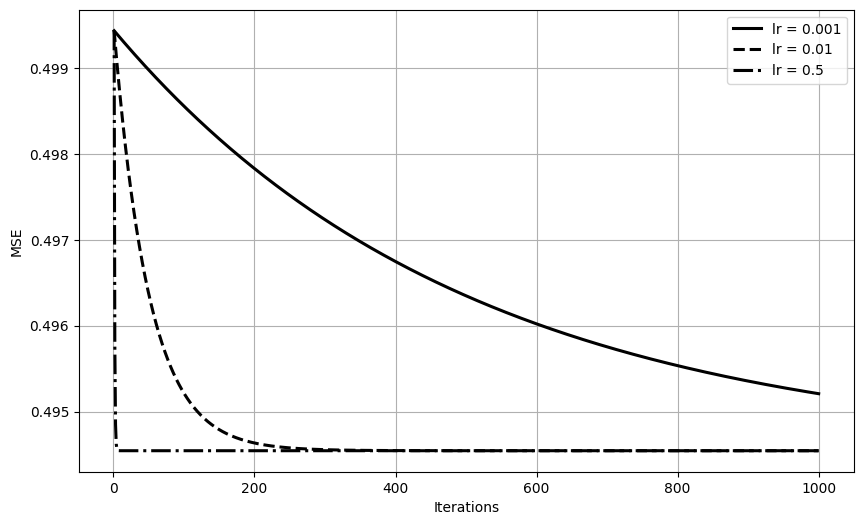

In [ ]:
master_dict = {}
for lr in [0.001, 0.01, 0.5]:
    w, b = 0, 0  # Starting guess for intercept and slope
    epochs = 1000  # Number of iterations
    w_orig, b_orig, MSE_record = gradient_descent(df, epochs, lr, w, b, norm=True)

    master_dict[lr] = MSE_record

visualise_MSE_vs_iter(master_dict)